# Train Loss vs Step — Parameter Golf Log Viewer
Load all log files from the `logs/` folder and plot `train_loss` as a function of `step`.

In [11]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
# Path to logs folder (relative to workspace root)
LOG_DIR = os.path.join("logs")
log_files = sorted(glob.glob(os.path.join(LOG_DIR, "*.txt")))
print(f"Found {len(log_files)} log files:")
for f in log_files:
    print(f"  {os.path.basename(f)}")

Found 33 log files:
  baseline_1311.txt
  baseline_sp1024.txt
  baseline_sp1024_algo_opt.txt
  baseline_sp1024_diff.txt
  baseline_sp1024_embed.txt
  baseline_sp1024_mla.txt
  baseline_sp1024_mla_256.txt
  baseline_sp1024_opt.txt
  baseline_sp1024_width4.txt
  baseline_sp1024_width4_dim1024.txt
  baseline_sp1024_width4_seq2048.txt
  fullA_8xh100.txt
  fullAttn_test_1h_adamw.txt
  fullAttn_test_1h_compare.txt
  fullAttn_test_1h_muon.txt
  l6_d768_M6.txt
  l6_d768_M6_8H100.txt
  light_baseline.txt
  qat_yarn_l11_d512_m3_s2048.txt
  qat_yarn_l11_d512_m4_s2048_4a100.txt
  qat_yarn_l12_d512_m6_s2048_4a100.txt
  qat_yarn_l9_d768_m4_s2048_4a100.txt
  qat_yarn_l9_d768_m4_s2048_8H100.txt
  s1024_l4_d768_mlp4.txt
  s1024_l6_d512_mlp3.txt
  s1024_l6_d512_mlp3_compile.txt
  s1024_l6_d512_mlp3_muon3.txt
  s2048_l7_d768_mlp4.txt
  s4096_l18_d256_mlp3.txt
  s4096_l4_d768_mlp6.txt
  s4096_l4_d768_mlp6_ema_lzma_pRope_LN.txt
  s4096_l4_d768_mlp6_ema_lzma_pRope_LN_q6_decay_wp.txt
  s4096_l4_d768_mlp6_ema

In [15]:
# Parse train_loss lines from each log file
# Format: "step:N/M train_loss:X.XXXX train_time:...ms step_avg:...ms"
pattern = re.compile(r"step:(\d+)/\d+\s+(?:train_)?loss:([\d.]+)")
batch_pattern = re.compile(r"train_batch_tokens:(\d+)")
world_pattern = re.compile(r"world_size:(\d+)")
accum_pattern = re.compile(r"grad_accum_steps:(\d+)")

EXCLUDE = {
    "baseline_sp1024", "fullAttn_test_1h_compare", "baseline_sp1024_diff","light_baseline","baseline_sp1024_embed",
    "baseline_sp1024_opt", "baseline_sp1024_width4", "fullAttn_test_1h_adamw", "qat_yarn_l11_d512_m3_s2048_1a100",
    "baseline_sp1024_width4_dim1024", "baseline_sp1024_width4_seq2048", "qat_yarn_l11_d512_m3_s2048", "fullAttn_test_1h_muon",
    "fullA_8xh100","baseline_sp1024_algo_opt","baseline_sp1024_mla_256","l6_d768_M6",
    "s1024_l4_d768_mlp4","s1024_l6_d512_mlp3","s1024_l6_d512_mlp3_compile","s1024_l6_d512_mlp3_muon3",
    }

all_data: dict[str, pd.DataFrame] = {}
for filepath in log_files:
    name = os.path.splitext(os.path.basename(filepath))[0]
    if name in EXCLUDE:
        print(f"{name}: excluded")
        continue
    steps, losses = [], []
    train_batch_tokens, world_size, grad_accum_steps = None, None, None
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if m:
                steps.append(int(m.group(1)))
                losses.append(float(m.group(2)))
            if train_batch_tokens is None:
                mb = batch_pattern.search(line)
                if mb:
                    train_batch_tokens = int(mb.group(1))
            if world_size is None:
                mw = world_pattern.search(line)
                if mw:
                    world_size = int(mw.group(1))
            if grad_accum_steps is None:
                ma = accum_pattern.search(line)
                if ma:
                    grad_accum_steps = int(ma.group(1))
    tokens_per_step = (train_batch_tokens or 524288)
    if steps:
        df = pd.DataFrame({"step": steps, "train_loss": losses}).sort_values("step")
        df["tokens"] = df["step"] * tokens_per_step
        all_data[name] = df
        print(f"{name}: {len(df)} entries, tokens_per_step={tokens_per_step} (batch={train_batch_tokens} ws={world_size} accum={grad_accum_steps})")
    else:
        print(f"{name}: no train_loss entries found")

baseline_1311: 18 entries, tokens_per_step=524288 (batch=None ws=None accum=None)
baseline_sp1024: excluded
baseline_sp1024_algo_opt: excluded
baseline_sp1024_diff: excluded
baseline_sp1024_embed: excluded
baseline_sp1024_mla: 48 entries, tokens_per_step=786432 (batch=786432 ws=1 accum=8)
baseline_sp1024_mla_256: excluded
baseline_sp1024_opt: excluded
baseline_sp1024_width4: excluded
baseline_sp1024_width4_dim1024: excluded
baseline_sp1024_width4_seq2048: excluded
fullA_8xh100: excluded
fullAttn_test_1h_adamw: excluded
fullAttn_test_1h_compare: excluded
fullAttn_test_1h_muon: excluded
l6_d768_M6: excluded
l6_d768_M6_8H100: 27 entries, tokens_per_step=786432 (batch=786432 ws=8 accum=1)
light_baseline: excluded
qat_yarn_l11_d512_m3_s2048: excluded
qat_yarn_l11_d512_m4_s2048_4a100: 49 entries, tokens_per_step=786432 (batch=786432 ws=4 accum=2)
qat_yarn_l12_d512_m6_s2048_4a100: 37 entries, tokens_per_step=786432 (batch=786432 ws=4 accum=2)
qat_yarn_l9_d768_m4_s2048_4a100: 45 entries, token

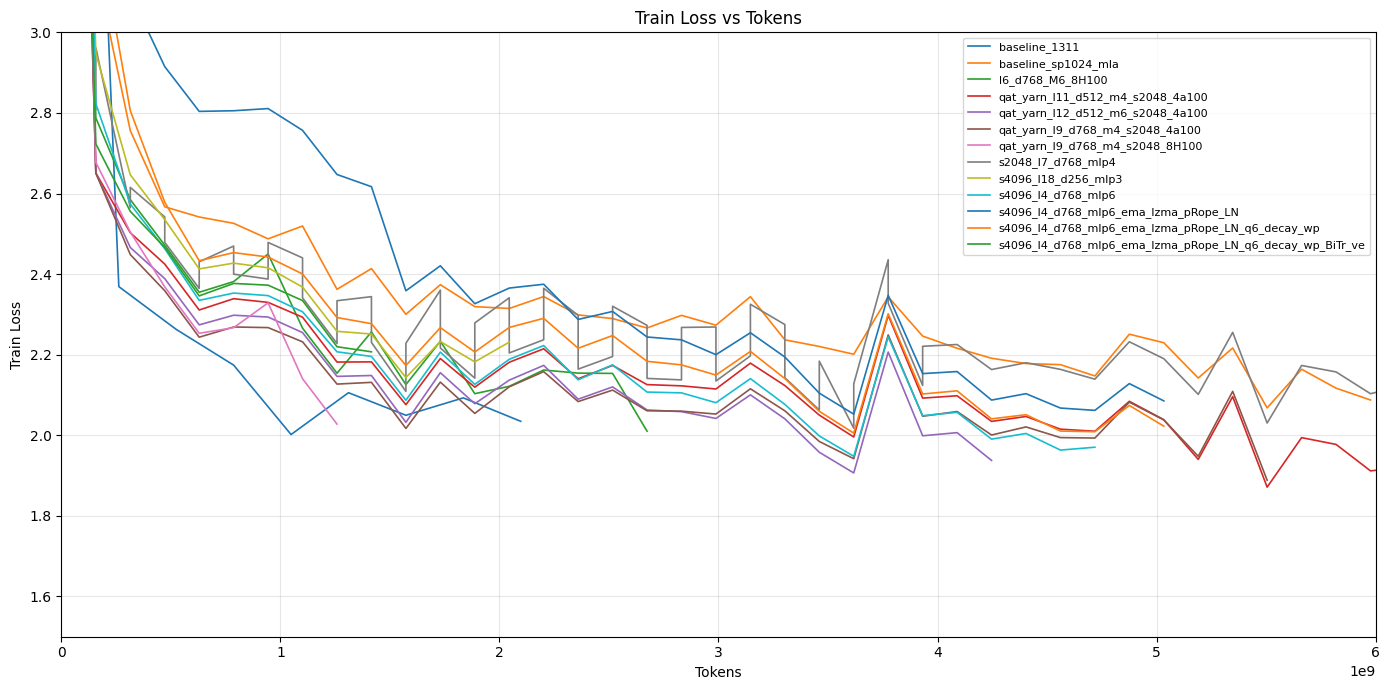

In [18]:
# Plot train_loss vs tokens for all log files
plt.figure(figsize=(14, 7))
for name, df in all_data.items():
    plt.plot(df["tokens"], df["train_loss"], label=name, linewidth=1.2)

plt.xlabel("Tokens")
plt.ylabel("Train Loss")
plt.ylim(1.5, 3)
plt.xlim(0, 6e9)
plt.title("Train Loss vs Tokens")
plt.legend(fontsize=8, loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()